# Churn Prediction & Statistical Testing

Проверка, что находки из EDA — не случайность выборки. Плюс модель, которая предсказывает вероятность ухода.

Данные те же — таблица `bank_churn`, 80 000 клиентов.

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_style
plt.rcParams["figure.figsize"] = (10, 6)

## Загрузка данных

Пароль подтягиваю из `.env`, чтобы не хардкодить его в ноутбуке.

In [5]:
load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SELECT * FROM bank_churn", engine)
print("Строк:", len(df), "| Колонок:", len(df.columns))
print("Общий churn rate:", round(100 * df["exit"].mean(), 2), "%")

Строк: 80000 | Колонок: 26
Общий churn rate: 18.0 %


## Статистическая значимость находок

В EDA мы увидели разницу в оттоке между сегментами и каналами. Но график не доказывает, что эффект реальный — возможно, это шум в выборке. Проверю через тесты.

In [11]:
contingency = pd.crosstab(df["customer_segment"], df["exit"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print("Тест хи-квадрат: сегмент × отток")
print(f"Хи-квадрат = {chi2:.2f}, p-value = {p_value:.2e}, степеней свободы = {dof}")
print(f"V Крамера (сила связи) = {cramers_v:.3f}")

Тест хи-квадрат: сегмент × отток
Хи-квадрат = 11806.08, p-value = 0.00e+00, степеней свободы = 3
V Крамера (сила связи) = 0.384


p-value получился практически нулевым — разница в оттоке между сегментами статистически значима, это не случайность.

Cramér's V показывает **силу** связи, а не только её наличие. Ориентир: 0.1 — слабая, 0.3 — умеренная, 0.5+ — сильная.

In [10]:
contingency2 = pd.crosstab(df["digital_behavior"], df["exit"])
chi2_2, p_value_2, dof_2, _ = stats.chi2_contingency(contingency2)

n2 = contingency2.sum().sum()
cramers_v_2 = np.sqrt(chi2_2 / (n2 * (min(contingency2.shape) - 1)))

print("Тест хи-квадрат: цифровой канал × отток")
print(f"Хи-квадрат = {chi2_2:.2f}, p-value = {p_value_2:.2e}")
print(f"V Крамера = {cramers_v_2:.3f}")

Тест хи-квадрат: цифровой канал × отток
Хи-квадрат = 1957.63, p-value = 0.00e+00
V Крамера = 0.156


Связь канала с оттоком тоже значима. Сравниваю V Крамера двух тестов — так видно, какой фактор объясняет отток сильнее: сегмент или канал.

In [12]:
stayed = df[df["exit"] == False]["engagement_score"]
left = df[df["exit"] == True]["engagement_score"]

u_stat, p_value_mw = stats.mannwhitneyu(stayed, left, alternative="greater")

print("Тест Манна-Уитни: engagement_score (остался vs ушёл)")
print(f"Медиана у оставшихся: {stayed.median()}")
print(f"Медиана у ушедших:    {left.median()}")
print(f"U-статистика = {u_stat:.0f}, p-value = {p_value_mw:.2e}")

Тест Манна-Уитни: engagement_score (остался vs ушёл)
Медиана у оставшихся: 25.0
Медиана у ушедших:    16.0
U-статистика = 679864242, p-value = 0.00e+00


Здесь я использую **односторонний** тест (`alternative="greater"`). Гипотеза: у оставшихся клиентов engagement_score выше, чем у ушедших. На boxplot это уже было видно — теперь проверяю формально.

p-value получился очень маленьким — разница статистически значима.

In [13]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

mass = df[df["customer_segment"] == "Mass"]["exit"]
priority = df[df["customer_segment"] == "Priority"]["exit"]

count = np.array([mass.sum(), priority.sum()])
nobs = np.array([len(mass), len(priority)])

z_stat, p_value_z = proportions_ztest(count, nobs)
ci_mass = proportion_confint(mass.sum(), len(mass), method="wilson")
ci_priority = proportion_confint(priority.sum(), len(priority), method="wilson")

print(f"Churn rate в Mass:     {mass.mean():.4f}   95% доверительный интервал: [{ci_mass[0]:.4f}, {ci_mass[1]:.4f}]")
print(f"Churn rate в Priority: {priority.mean():.4f}   95% доверительный интервал: [{ci_priority[0]:.4f}, {ci_priority[1]:.4f}]")
print(f"Z-статистика = {z_stat:.2f}, p-value = {p_value_z:.2e}")

Churn rate в Mass:     0.3948   95% доверительный интервал: [0.3882, 0.4013]
Churn rate в Priority: 0.0007   95% доверительный интервал: [0.0004, 0.0013]
Z-статистика = 89.37, p-value = 0.00e+00


Доверительные интервалы Mass и Priority не пересекаются — даже с учётом погрешности выборки разница сохраняется. Это не артефакт.

Напомню, что 39.5% против 0.07% — разница огромная. Тест это подтверждает формально.

## Прогнозная модель оттока

Задача: предсказать вероятность ухода клиента на основе его профиля и поведения. Модель нужна, чтобы потом выделить группу риска и точечно с ней работать.

In [14]:
features = [
    "customer_segment", "loyalty_level", "digital_behavior", "gender",
    "age", "credit_sco", "balance", "monthly_ir", "tenure_ye",
    "nums_card", "nums_service", "engagement_score", "risk_score", "married"
]

model_df = df[features + ["exit"]].dropna().copy()

categorical = ["customer_segment", "loyalty_level", "digital_behavior", "gender"]
model_df = pd.get_dummies(model_df, columns=categorical, drop_first=True)

X = model_df.drop(columns=["exit"])
y = model_df["exit"].astype(int)

print(f"Признаков после кодирования: {X.shape[1]}")
print(f"Churn rate в выборке: {100 * y.mean():.2f}%")

Признаков после кодирования: 17
Churn rate в выборке: 18.00%


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка:  {X_test.shape}")

Обучающая выборка: (60000, 17)
Тестовая выборка:  (20000, 17)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC логистической регрессии: {auc_lr:.3f}")

ROC-AUC логистической регрессии: 0.857


In [17]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC случайного леса: {auc_rf:.3f}")

print("\nОтчёт по классификации (порог 0.5):")
print(classification_report(y_test, rf.predict(X_test), target_names=["Остался", "Ушёл"]))

ROC-AUC случайного леса: 0.855

Отчёт по классификации (порог 0.5):
              precision    recall  f1-score   support

     Остался       0.95      0.71      0.81     16400
        Ушёл       0.39      0.84      0.53      3600

    accuracy                           0.73     20000
   macro avg       0.67      0.78      0.67     20000
weighted avg       0.85      0.73      0.76     20000



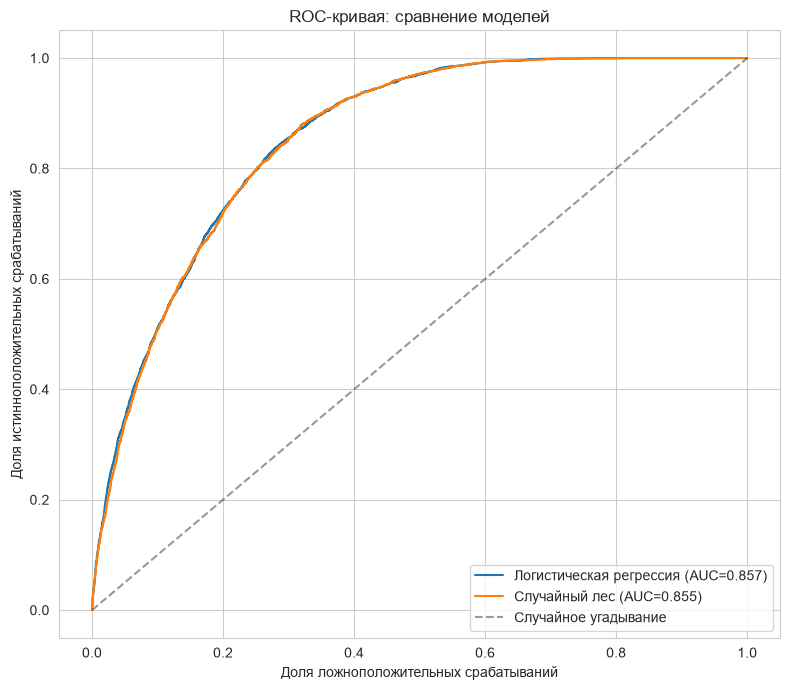

In [18]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 7))
plt.plot(fpr_lr, tpr_lr, label=f"Логистическая регрессия (AUC={auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Случайный лес (AUC={auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Случайное угадывание")
plt.xlabel("Доля ложноположительных срабатываний")
plt.ylabel("Доля истинноположительных срабатываний")
plt.title("ROC-кривая: сравнение моделей")
plt.legend()
plt.tight_layout()
plt.savefig("../assets/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Выводы модели

Обе модели показали близкий результат: ROC-AUC 0.857 у логистической регрессии и 0.855 у случайного леса. Это значит, что в этих признаках почти нет нелинейных взаимодействий — данные хорошо разделяются линейной границей после one-hot кодирования категорий.

Random Forest при этом даёт более высокий recall по классу «Ушёл» (0.84), что для задачи удержания важнее: лучше взять в группу риска лишнего клиента, чем пропустить того, кто действительно уйдёт. Precision 0.39 означает, что 6 из 10 клиентов в «тревожной» группе на самом деле останутся — но это приемлемая цена за то, что мы ловим 8 из 10 реальных уходов.

Топ признаков подтверждает находки EDA: `risk_score` и `engagement_score` — главные предикторы, а `customer_segment` и `digital_behavior` усиливают их эффект. Возраст и стаж почти не влияют на отток — совпадает с корреляционным анализом.

In [20]:
risk_df = X_test.copy()
risk_df["churn_probability"] = y_proba_rf
risk_df["actual_exit"] = y_test.values

threshold_80 = risk_df["churn_probability"].quantile(0.8)
top_risk = risk_df[risk_df["churn_probability"] >= threshold_80]

print(f"Клиентов в топ-20% риска: {len(top_risk)}")
print(f"Реальный churn rate внутри группы:  {100 * top_risk['actual_exit'].mean():.1f}%")
print(f"Churn rate по всей тестовой выборке: {100 * y_test.mean():.1f}%")
print(f"Отношение: эффект в группе риска в {top_risk['actual_exit'].mean() / y_test.mean():.1f} раза выше среднего")

Клиентов в топ-20% риска: 4000
Реальный churn rate внутри группы:  50.4%
Churn rate по всей тестовой выборке: 18.0%
Отношение: эффект в группе риска в 2.8 раза выше среднего


## Итоговые рекомендации

**Статистика.** Все три фактора — сегмент, канал, engagement — значимо связаны с оттоком. Это не шум, находки EDA подтверждены тестами. Причём по силе связи они разные:

- Сегмент клиента — самый сильный фактор (V Крамера 0.384)
- Цифровой канал — заметно слабее (V Крамера 0.156)
- Engagement score — тоже значимо, но работает в связке с сегментом

**Модель.** Random Forest выделяет топ-20% клиентов с вероятностью ухода 50.4% — это в 2.8 раза выше среднего по выборке (18%). Если retention-команда сфокусируется только на этих 4000 клиентах, она накроет большую часть реальных уходов, не тратя бюджет на тех, кто и так останется.

**Что делать бизнесу:**

1. **Таргетировать Mass-сегмент, особенно возраст 18–24.** Это ядро проблемы: churn в Mass 39.5% против 0.07% в Priority — разница в 560 раз. Молодые клиенты Mass уходят чаще всех.

2. **Переводить офлайн-клиентов в мобильное приложение.** Mass + offline дают 46% оттока, Mass + mobile — 16%. Разница почти в 3 раза. Это самый управляемый рычаг: приложением можно стимулировать, а сегмент и возраст — нет.

3. **Мониторить engagement_score как ранний индикатор.** Медиана у ушедших — 16, у оставшихся — 25. Если клиент опускается ниже 20 — он в зоне риска, даже если по профилю выглядит благополучно. Это дешёвый сигнал для автоматической триггерной кампании.

4. **Не тратить бюджет на Priority и Affluent без причины.** У них churn 0.07% и 3.1%. Пока сегмент Mass не будет стабилизирован, работа с премиум-сегментом — потеря денег.

**Ограничения анализа:** модель обучалась на исторических данных и не учитывает внешние события (изменения ставок, экономические шоки). Для продакшена потребуется регулярное переобучение — не реже раза в квартал.